# Taller Uruguay — Atlas Urbano 2020–2024

Este notebook permite explorar cambios del **Atlas Urbano** en Uruguay entre 2020 y 2024.

El flujo mantiene un enfoque pedagógico: primero se selecciona el área de análisis, luego se revisan los productos del Atlas Urbano y finalmente se calculan indicadores territoriales a partir de sus clases.

**Unidad de análisis:** departamento completo o municipio seleccionado.

**Productos usados:** Atlas Urbano 2020 y 2024 en formato GeoTIFF y límites municipales de Uruguay.

> Los productos principales se leen directamente desde `UA_UY_2020.tif` y `UA_UY_2024.tif`. No se requieren VRT, ZIP, mosaicos auxiliares ni imágenes Sentinel-2.

## Flujo de trabajo

1. Cargar librerías y configurar rutas.
2. Leer el Atlas Urbano 2020/2024 y la capa de municipios.
3. Seleccionar un departamento y luego un municipio, o bien todo el departamento.
4. Verificar el área de análisis.
5. Recortar y alinear los raster 2020/2024.
6. Corregir el cálculo de áreas para evitar sesgos por sistemas de coordenadas no equivalentes en superficie.
7. Visualizar el Atlas Urbano 2020 y 2024.
8. Calcular composición de clases y variación multitemporal.
9. Analizar superficie construida total.
10. Identificar origen y destino de nuevas superficies construidas.
11. Generar mapas de cambio urbano.
12. Exportar tablas, figuras y raster para QGIS.
13. Generar un resumen interpretativo automático.

In [1]:
# ============================================================
# 0. LIBRERÍAS
# ============================================================

from pathlib import Path
import shutil
import unicodedata
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.plot import plotting_extent
from rasterio.warp import reproject, Resampling
from rasterio.features import geometry_mask
from shapely.geometry import box, mapping

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

try:
    import ipywidgets as widgets
    from IPython.display import clear_output
    WIDGETS_DISPONIBLES = True
except Exception:
    WIDGETS_DISPONIBLES = False
    print("ipywidgets no está disponible. Se usará selección manual.")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ============================================================
# 1. CONFIGURACIÓN PRINCIPAL
# ============================================================

PREFIJO_PRODUCTO = "au"
PAIS = "uruguay"
ANIO_1 = 2020
ANIO_2 = 2024
ANIOS = [ANIO_1, ANIO_2]

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name.lower() == "notebooks" else NOTEBOOK_DIR

DATA_DIR = PROJECT_DIR / "data"
RASTERS_AU_DIR = DATA_DIR / "rasters_AU"
SHAPES_AU_DIR = DATA_DIR / "shapes_AU"
QML_PATH = DATA_DIR / "CRC_AU_ES.qml"

RASTER_AU_2020 = RASTERS_AU_DIR / "2020" / "AU_UY_2020.tif"
RASTER_AU_2024 = RASTERS_AU_DIR / "2024" / "AU_UY_2024.tif"

MUNICIPIOS_PATH = SHAPES_AU_DIR / "municipios_20250507.shp"
MUNICIPIOS_CST_PATH = SHAPES_AU_DIR / "municipios_20250507.cst"

OUTPUTS_DIR = PROJECT_DIR / "outputs" / "output_AU" / "1_Analisis_atlas_urbano"
OUTPUT_FIGURES_DIR = OUTPUTS_DIR / "figures"
OUTPUT_TABLES_DIR = OUTPUTS_DIR / "tables"
OUTPUT_QGIS_DIR = OUTPUTS_DIR / "qgis"
for folder in [OUTPUT_FIGURES_DIR, OUTPUT_TABLES_DIR, OUTPUT_QGIS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

IGNORE_VALUES = [0]
CORREGIR_AREA_RASTER = True
USAR_HUELLA_COMUN_2020_2024 = True
DEPTO_MANUAL = "MONTEVIDEO"
MUNICIPIO_MANUAL = "TODO EL DEPARTAMENTO"

print("Directorio del proyecto:", PROJECT_DIR)
print("Raster AU 2020:", RASTER_AU_2020)
print("Raster AU 2024:", RASTER_AU_2024)
print("Municipios:", MUNICIPIOS_PATH)
print("Outputs:", OUTPUTS_DIR)

Directorio del proyecto: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay
Raster AU 2020: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\data\rasters_AU\2020\AU_UY_2020.tif
Raster AU 2024: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\data\rasters_AU\2024\AU_UY_2024.tif
Municipios: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\data\shapes_AU\municipios_20250507.shp
Outputs: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU


In [3]:
# ============================================================
# 1.1 LEYENDA DEL ATLAS URBANO
# ============================================================

CLASES_AU = {
    4368: "Residencial",
    4384: "Comercial/Industrial",
    4400: "Edificios",
    4624: "Calles y ferrocarriles",
    4640: "Aeropuertos",
    5136: "Vegetación boscosa",
    5152: "Agricultura",
    5168: "Recreación",
    5184: "Otros espacios abiertos",
    36880: "Extracción de minerales",
    45056: "Cuerpos de agua",
}

CLASES_CONSTRUIDAS = {k: CLASES_AU[k] for k in [4368, 4384, 4400, 4624, 4640]} #residencial, comercial, edificios, calles y aeropuertos.

AU_COLORS = {
    0: "#ffffff",
    4368: "#ffe680",
    4384: "#cd6667",
    4400: "#9986f7",
    4624: "#f2f2f2",
    4640: "#676767",
    5136: "#31a354",
    5152: "#f1a3d3",
    5168: "#ff6666",
    5184: "#8c564b",
    36880: "#fdbf6f",
    45056: "#4a90e2",
}

def nombre_clase(value):
    return CLASES_AU.get(int(value), f"Clase {int(value)}")

def color_clase(value):
    return AU_COLORS.get(int(value), "#cccccc")

In [20]:
# ============================================================
# 2. FUNCIONES AUXILIARES
# ============================================================

def normalizar_texto(texto):
    texto = str(texto).strip()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    texto = " ".join(texto.split())
    return texto.upper()

def reparar_mojibake(texto):
    if pd.isna(texto):
        return texto
    s = str(texto).strip()
    if "Ã" in s or "Â" in s:
        for enc in ["latin1", "cp1252"]:
            try:
                return s.encode(enc).decode("utf-8")
            except Exception:
                pass
    return s

def safe_name(texto):
    texto = reparar_mojibake(texto)
    texto = unicodedata.normalize("NFKD", str(texto))
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    texto = texto.lower().replace("ñ", "n")
    chars = []
    for c in texto:
        if c.isalnum():
            chars.append(c)
        elif c in [" ", "-", "_", "/"]:
            chars.append("_")
    salida = "".join(chars)
    while "__" in salida:
        salida = salida.replace("__", "_")
    return salida.strip("_")

def union_geometria(gdf):
    return gdf.geometry.unary_union

def area_km2_geometria(gdf):
    try:
        crs_area = gdf.estimate_utm_crs()
        if crs_area is None:
            crs_area = "EPSG:6933"
    except Exception:
        crs_area = "EPSG:6933"
    return gdf.to_crs(crs_area).geometry.unary_union.area / 1_000_000

def pixel_area_km2(profile):
    transform = profile["transform"]
    return abs(transform.a * transform.e) / 1_000_000

def bounds_gdf_from_raster(raster_path):
    with rasterio.open(raster_path) as src:
        b = src.bounds
        return gpd.GeoDataFrame({"raster": [Path(raster_path).name]}, geometry=[box(b.left, b.bottom, b.right, b.top)], crs=src.crs)

def guardar_figura(fig, path, dpi=180):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Figura guardada:", path)

def display_fig(fig):
    display(fig)
    plt.close(fig)

def construir_cmap_discreto(values, include_nodata=True):
    vals = sorted(set(int(v) for v in values))
    if include_nodata and 0 not in vals:
        vals = [0] + vals
    colors = [color_clase(v) for v in vals]
    bounds = [v - 0.5 for v in vals] + [vals[-1] + 0.5]
    return ListedColormap(colors), BoundaryNorm(bounds, len(colors)), vals

def copiar_qml_si_existe(destino_tif):
    destino_tif = Path(destino_tif)
    if QML_PATH.exists():
        destino_qml = destino_tif.with_suffix(".qml")
        shutil.copy(QML_PATH, destino_qml)
        return destino_qml
    return None

def hex_a_rgba(hex_color):
    hex_color = hex_color.lstrip("#")

    if len(hex_color) == 6:
        r = int(hex_color[0:2], 16)
        g = int(hex_color[2:4], 16)
        b = int(hex_color[4:6], 16)
        return (r, g, b, 255)
    raise ValueError(f"Color hexadecimal no válido: {hex_color}")

def exportar_raster(
    arr,
    profile,
    out_path,
    nodata=0,
    dtype=None,
    info_colores=None,):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    prof = profile.copy()

    if dtype is None:
        dtype = arr.dtype

    prof.update(
        driver="GTiff",
        height=arr.shape[0],
        width=arr.shape[1],
        count=1,
        dtype=dtype,
        nodata=nodata,
        compress="lzw",)

    with rasterio.open(out_path, "w", **prof) as dst:
        dst.write(arr.astype(dtype), 1)
        if info_colores is not None:
            colormap = {
                int(codigo): hex_a_rgba(info["color"])
                for codigo, info in info_colores.items()
            }
            dst.write_colormap(1, colormap)
    print("Raster exportado:", out_path)
    return out_path

def preparar_output_dirs(depto, municipio):
    depto_safe = safe_name(depto)
    muni_safe = "todo_departamento" if municipio == "TODO EL DEPARTAMENTO" else safe_name(municipio)
    base = f"{PREFIJO_PRODUCTO}_{PAIS}_{depto_safe}_{muni_safe}"
    for folder in [OUTPUT_FIGURES_DIR, OUTPUT_TABLES_DIR, OUTPUT_QGIS_DIR]:
        folder.mkdir(parents=True, exist_ok=True)
    return {"figures": OUTPUT_FIGURES_DIR, "tables": OUTPUT_TABLES_DIR, "qgis": OUTPUT_QGIS_DIR, "base": base}

## 3. Carga de datos

Se cargan los productos **Atlas Urbano 2020 y 2024** y la capa municipal.

También se filtran los municipios que intersectan la huella común de ambos raster. Esta será la base espacial utilizada por el selector interactivo del taller.

In [5]:
# ============================================================
# 3. CARGA DE INSUMOS
# ============================================================

def leer_encoding_cst(cst_path):
    if Path(cst_path).exists():
        txt = Path(cst_path).read_text(encoding="utf-8", errors="ignore").strip()
        return txt if txt else None
    return None

def leer_municipios_uy(shp_path):
    encoding_cst = leer_encoding_cst(MUNICIPIOS_CST_PATH)
    encodings = []
    if encoding_cst is not None:
        encodings.append(encoding_cst)
    encodings += [None, "latin1", "cp1252", "utf-8"]
    ultimo_error = None
    for enc in encodings:
        try:
            gdf = gpd.read_file(shp_path, encoding=enc) if enc is not None else gpd.read_file(shp_path)
            print("Municipios leídos con encoding:", enc if enc is not None else "automático")
            break
        except Exception as e:
            ultimo_error = e
            gdf = None
    if gdf is None:
        raise RuntimeError(f"No se pudo leer la capa de municipios. Último error: {ultimo_error}")
    faltantes = [c for c in ["depto", "municipio"] if c not in gdf.columns]
    if faltantes:
        raise ValueError(f"Faltan columnas necesarias: {faltantes}")
    for col in ["depto", "municipio"]:
        gdf[col] = gdf[col].apply(reparar_mojibake).astype(str).str.strip()
    gdf["depto_norm"] = gdf["depto"].apply(normalizar_texto)
    gdf["municipio_norm"] = gdf["municipio"].apply(normalizar_texto)
    return gdf

for p in [RASTER_AU_2020, RASTER_AU_2024, MUNICIPIOS_PATH]:
    if not Path(p).exists():
        print("ADVERTENCIA: no se encontró", p)

municipios_gdf = leer_municipios_uy(MUNICIPIOS_PATH)
huella_2020 = bounds_gdf_from_raster(RASTER_AU_2020)
huella_2024 = bounds_gdf_from_raster(RASTER_AU_2024)

if USAR_HUELLA_COMUN_2020_2024:
    huella_au = gpd.overlay(huella_2020.to_crs("EPSG:3857"), huella_2024.to_crs("EPSG:3857"), how="intersection").to_crs(municipios_gdf.crs)
    print("Se usará la huella común entre AU 2020 y AU 2024.")
else:
    huella_au = gpd.GeoDataFrame(geometry=[union_geometria(pd.concat([huella_2020.to_crs(municipios_gdf.crs), huella_2024.to_crs(municipios_gdf.crs)], ignore_index=True))], crs=municipios_gdf.crs)
    print("Se usará la unión de huellas AU 2020 y AU 2024.")

geom_huella = union_geometria(huella_au)
municipios_au_gdf = municipios_gdf[municipios_gdf.intersects(geom_huella)].copy().reset_index(drop=True)

print("Municipios totales:", len(municipios_gdf))
print("Municipios que intersectan la huella AU:", len(municipios_au_gdf))
print("Departamentos disponibles:", municipios_au_gdf["depto"].nunique())
display(municipios_au_gdf[["depto", "municipio"]].sort_values(["depto", "municipio"]).head(20))

Municipios leídos con encoding: ISO-8859-1
Se usará la huella común entre AU 2020 y AU 2024.
Municipios totales: 136
Municipios que intersectan la huella AU: 38
Departamentos disponibles: 5


,depto,municipio
5,CANELONES,18 DE MAYO
11,CANELONES,AGUAS CORRIENTES
33,CANELONES,ATLÁNTIDA
17,CANELONES,BARROS BLANCOS
7,CANELONES,CANELONES
20,CANELONES,CIUDAD DE LA COSTA
0,CANELONES,COLONIA NICOLICH
3,CANELONES,DEL ANDALUZ
15,CANELONES,EMPALME OLMOS
14,CANELONES,JUANICÓ


## 4. Selección del área de análisis

Primero se selecciona un **departamento**. Luego el notebook despliega los municipios disponibles dentro de ese departamento. La opción **TODO EL DEPARTAMENTO** une todos los municipios disponibles del departamento seleccionado.

**Pregunta guía:** ¿qué escala de análisis resulta más adecuada: municipio o departamento completo?

In [6]:
# ============================================================
# 4. SELECCIÓN INTERACTIVA DE DEPARTAMENTO Y MUNICIPIO
# ============================================================

DEPTO_SELECCIONADO = None
MUNICIPIO_SELECCIONADO = None
AREA_SELECCIONADA = None
analysis_gdf = None
out_dirs = None
base = None
AREA_CONFIRMADA = False

def opciones_municipios_para_depto(depto):
    munis = municipios_au_gdf.loc[municipios_au_gdf["depto"] == depto, "municipio"].dropna().sort_values().unique().tolist()
    return ["TODO EL DEPARTAMENTO"] + munis

def construir_area_analisis(depto, municipio):
    if municipio == "TODO EL DEPARTAMENTO":
        gdf = municipios_au_gdf[municipios_au_gdf["depto"] == depto].copy()
        area_nombre = f"{depto} — TODO EL DEPARTAMENTO"
    else:
        gdf = municipios_au_gdf[(municipios_au_gdf["depto"] == depto) & (municipios_au_gdf["municipio"] == municipio)].copy()
        area_nombre = f"{depto} — {municipio}"
    if gdf.empty:
        raise ValueError("La selección no contiene geometrías. Revisa departamento/municipio.")
    return gdf, area_nombre

def confirmar_area(depto, municipio):
    global DEPTO_SELECCIONADO, MUNICIPIO_SELECCIONADO, AREA_SELECCIONADA, analysis_gdf, out_dirs, base, AREA_CONFIRMADA
    DEPTO_SELECCIONADO = depto
    MUNICIPIO_SELECCIONADO = municipio
    analysis_gdf, AREA_SELECCIONADA = construir_area_analisis(depto, municipio)
    out_dirs = preparar_output_dirs(depto, municipio)
    base = out_dirs["base"]
    AREA_CONFIRMADA = True
    print("Área confirmada:", AREA_SELECCIONADA)
    print("Número de geometrías:", len(analysis_gdf))
    print("Área vectorial aproximada:", round(area_km2_geometria(analysis_gdf), 3), "km²")
    print("Prefijo de salida:", base)
    display(analysis_gdf[["depto", "municipio"]].sort_values(["depto", "municipio"]).head(25))

if WIDGETS_DISPONIBLES:
    deptos = sorted(municipios_au_gdf["depto"].dropna().unique().tolist())
    depto_widget = widgets.Dropdown(options=deptos, value=deptos[0] if deptos else None, description="Departamento:", style={"description_width": "initial"}, layout=widgets.Layout(width="420px"))
    municipio_widget = widgets.Dropdown(options=opciones_municipios_para_depto(depto_widget.value), description="Municipio:", style={"description_width": "initial"}, layout=widgets.Layout(width="520px"))
    boton_confirmar = widgets.Button(description="Confirmar área", button_style="success", icon="check")
    salida_confirmacion = widgets.Output()
    def actualizar_municipios(change):
        municipio_widget.options = opciones_municipios_para_depto(change["new"])
        municipio_widget.value = municipio_widget.options[0]
    def on_confirmar_clicked(b):
        with salida_confirmacion:
            clear_output()
            confirmar_area(depto_widget.value, municipio_widget.value)
    depto_widget.observe(actualizar_municipios, names="value")
    boton_confirmar.on_click(on_confirmar_clicked)
    display(widgets.VBox([depto_widget, municipio_widget, boton_confirmar, salida_confirmacion]))
else:
    print("Selección manual activa.")
    confirmar_area(DEPTO_MANUAL, MUNICIPIO_MANUAL)

### 4.1 Confirmación manual opcional

Usa esta celda si quieres ejecutar el notebook sin widgets.

In [7]:
# ============================================================
# 4.1 CONFIRMACIÓN MANUAL OPCIONAL
# ============================================================

# Descomenta esta línea si quieres saltarte los widgets.
# confirmar_area(DEPTO_MANUAL, MUNICIPIO_MANUAL)

## 5. Verificación espacial del área seleccionada

Antes de calcular indicadores, revisamos si el área seleccionada intersecta correctamente los productos AU 2020 y 2024. Esto ayuda a evitar errores de selección y permite confirmar la escala del análisis.

Figura guardada: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU\figures\au_uruguay_montevideo_c_verificacion_area.png


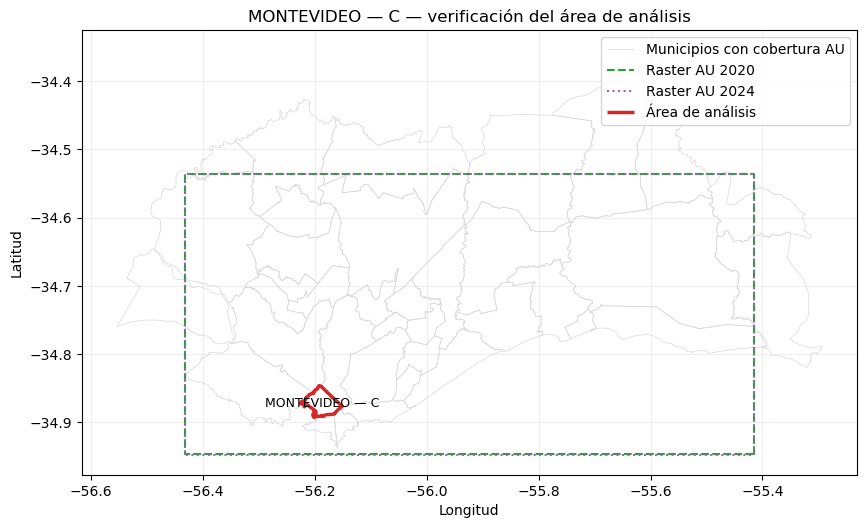

In [9]:
# ============================================================
# 5. MAPA DE VERIFICACIÓN DEL ÁREA SELECCIONADA
# ============================================================

def plot_verificacion_area():
    if not AREA_CONFIRMADA:
        raise RuntimeError("Primero debes confirmar un área de análisis en la sección 4.")
    target_crs = "EPSG:4326"
    fig, ax = plt.subplots(figsize=(10, 8))
    municipios_au_gdf.to_crs(target_crs).boundary.plot(ax=ax, color="0.85", linewidth=0.5, label="Municipios con cobertura AU")
    huella_2020.to_crs(target_crs).boundary.plot(ax=ax, color="#2ca02c", linewidth=1.5, linestyle="--", label=f"Raster AU {ANIO_1}")
    huella_2024.to_crs(target_crs).boundary.plot(ax=ax, color="#9467bd", linewidth=1.5, linestyle=":", label=f"Raster AU {ANIO_2}")
    analysis_gdf.to_crs(target_crs).boundary.plot(ax=ax, color="#d62728", linewidth=2.5, label="Área de análisis")
    centro = gpd.GeoSeries([union_geometria(analysis_gdf)], crs=analysis_gdf.crs).to_crs(target_crs).iloc[0].centroid
    ax.text(centro.x, centro.y, AREA_SELECCIONADA, fontsize=9, ha="center", va="center")
    ax.set_title(f"{AREA_SELECCIONADA} — verificación del área de análisis")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.grid(alpha=0.2)
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), loc="best")
    guardar_figura(fig, out_dirs["figures"] / f"{base}_verificacion_area.png")
    display_fig(fig)

plot_verificacion_area()

## 6. Recorte, alineación y corrección de área

Los productos AU están en `EPSG:3857`, una proyección que no conserva áreas. Por eso el notebook aplica una corrección interna del área de píxel antes de calcular superficies en km². El usuario no necesita ajustar nada manualmente.

In [10]:
# ============================================================
# 6. RECORTE, ALINEACIÓN Y CORRECCIÓN DE ÁREA
# ============================================================

def recortar_raster_a_geometria(raster_path, gdf, nodata=0):
    """
    Recorta un raster usando la geometría seleccionada.

    Nota:
    Se usa indexes=[1] y no indexes=1 para asegurar que rasterio devuelva
    un arreglo 3D con forma (banda, filas, columnas).
    """
    with rasterio.open(raster_path) as src:
        gdf_proj = gdf.to_crs(src.crs)

        shapes = [
            mapping(geom)
            for geom in gdf_proj.geometry
            if geom is not None and not geom.is_empty
        ]

        if len(shapes) == 0:
            raise ValueError("La geometría de análisis está vacía o no contiene geometrías válidas.")

        arr, transform = mask(
            src,
            shapes,
            crop=True,
            filled=True,
            nodata=nodata,
            indexes=[1]
        )

        profile = src.profile.copy()

        profile.update(
            height=arr.shape[1],
            width=arr.shape[2],
            transform=transform,
            count=1,
            nodata=nodata
        )

    return arr[0], profile


def alinear_a_grilla_base(arr_src, profile_src, profile_base, nodata=0):
    """
    Alinea un raster recortado a la grilla base.
    En este taller usamos AU 2020 como grilla base.
    """

    destino = np.full(
        (profile_base["height"], profile_base["width"]),
        nodata,
        dtype=arr_src.dtype
    )

    reproject(
        source=arr_src,
        destination=destino,
        src_transform=profile_src["transform"],
        src_crs=profile_src["crs"],
        src_nodata=nodata,
        dst_transform=profile_base["transform"],
        dst_crs=profile_base["crs"],
        dst_nodata=nodata,
        resampling=Resampling.nearest
    )

    return destino


if not AREA_CONFIRMADA:
    raise RuntimeError("Primero debes confirmar un área de análisis en la sección 4.")


# ------------------------------------------------------------
# Recorte de Atlas Urbano 2020 y 2024
# ------------------------------------------------------------

arr_2020, profile_2020 = recortar_raster_a_geometria(
    RASTER_AU_2020,
    analysis_gdf,
    nodata=0
)

arr_2024_tmp, profile_2024_tmp = recortar_raster_a_geometria(
    RASTER_AU_2024,
    analysis_gdf,
    nodata=0
)


# ------------------------------------------------------------
# Alineación 2024 a la grilla base 2020
# ------------------------------------------------------------

arr_2024 = alinear_a_grilla_base(
    arr_2024_tmp,
    profile_2024_tmp,
    profile_2020,
    nodata=0
)

profile_2024 = profile_2020.copy()


# ------------------------------------------------------------
# Corrección de área para rasters en EPSG:3857
# ------------------------------------------------------------

geom_raster_crs = analysis_gdf.to_crs(profile_2020["crs"])

geom_mask = geometry_mask(
    [
        geom
        for geom in geom_raster_crs.geometry
        if geom is not None and not geom.is_empty
    ],
    out_shape=arr_2020.shape,
    transform=profile_2020["transform"],
    invert=True,
    all_touched=False
)

AREA_VECTORIAL_REAL_KM2 = area_km2_geometria(analysis_gdf)

AREA_RASTERIZADA_PROYECTADA_KM2 = (
    geom_mask.sum() * pixel_area_km2(profile_2020)
)

if CORREGIR_AREA_RASTER and geom_mask.sum() > 0:
    FACTOR_CORRECCION_AREA = (
        AREA_VECTORIAL_REAL_KM2 / AREA_RASTERIZADA_PROYECTADA_KM2
    )
    PX_AREA_KM2_ANALISIS = (
        pixel_area_km2(profile_2020) * FACTOR_CORRECCION_AREA
    )
else:
    FACTOR_CORRECCION_AREA = 1.0
    PX_AREA_KM2_ANALISIS = pixel_area_km2(profile_2020)


# ------------------------------------------------------------
# Resumen técnico breve
# ------------------------------------------------------------

print("Shape AU 2020:", arr_2020.shape)
print("Shape AU 2024 alineado:", arr_2024.shape)
print("CRS raster:", profile_2020["crs"])
print("Corrección de área aplicada:", CORREGIR_AREA_RASTER)
print("Factor de corrección de área:", round(FACTOR_CORRECCION_AREA, 6))
print("Área por píxel usada en indicadores:", PX_AREA_KM2_ANALISIS, "km²")

Shape AU 2020: (536, 856)
Shape AU 2024 alineado: (536, 856)
CRS raster: EPSG:4326
Corrección de área aplicada: True
Factor de corrección de área: 10136829386.339693
Área por píxel usada en indicadores: 7.660653357849636e-05 km²


## 7. Distribución de clases y variación multitemporal

Se calcula la superficie por clase en ambos años y su variación neta. La lectura debe considerar tanto los valores absolutos como los porcentajes del área válida.

,anio,class_id,class_name,area_km2,porcentaje_area,pixeles,es_construida
0,2020,4400,Edificios,11.804,68.394,154089,True
1,2020,4624,Calles y ferrocarriles,2.287,13.252,29857,True
2,2020,4368,Residencial,1.610,9.330,21021,True
3,2020,5168,Recreación,1.038,6.017,13556,False
4,2020,4384,Comercial/Industrial,0.286,1.657,3733,True
5,2020,5136,Vegetación boscosa,0.103,0.598,1347,False
6,2020,45056,Cuerpos de agua,0.087,0.507,1142,False
7,2020,5184,Otros espacios abiertos,0.023,0.131,296,False
8,2020,4640,Aeropuertos,0.015,0.087,195,True
9,2020,5152,Agricultura,0.005,0.027,61,False


,class_id,class_name,area_2020_km2,porcentaje_2020,es_construida,area_2024_km2,porcentaje_2024,delta_area_km2,delta_porcentaje_puntos,variacion_pct_relativa
0,4368,Residencial,1.610,9.330,True,1.820,10.544,0.209,1.213,13.001
1,4400,Edificios,11.804,68.394,True,11.927,69.107,0.123,0.713,1.042
2,45056,Cuerpos de agua,0.087,0.507,False,0.130,0.755,0.043,0.249,49.037
3,4624,Calles y ferrocarriles,2.287,13.252,True,2.301,13.331,0.013,0.078,0.589
4,5184,Otros espacios abiertos,0.023,0.131,False,0.025,0.147,0.003,0.016,11.824
5,5152,Agricultura,0.005,0.027,False,0.000,0.000,-0.005,-0.027,-100.000
6,4640,Aeropuertos,0.015,0.087,True,0.007,0.041,-0.008,-0.045,-52.308
7,5136,Vegetación boscosa,0.103,0.598,False,0.055,0.321,-0.048,-0.277,-46.325
8,4384,Comercial/Industrial,0.286,1.657,True,0.208,1.208,-0.078,-0.449,-27.110
9,5168,Recreación,1.038,6.017,False,0.785,4.547,-0.254,-1.470,-24.432


Figura guardada: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU\figures\au_uruguay_montevideo_c_composicion_clases.png


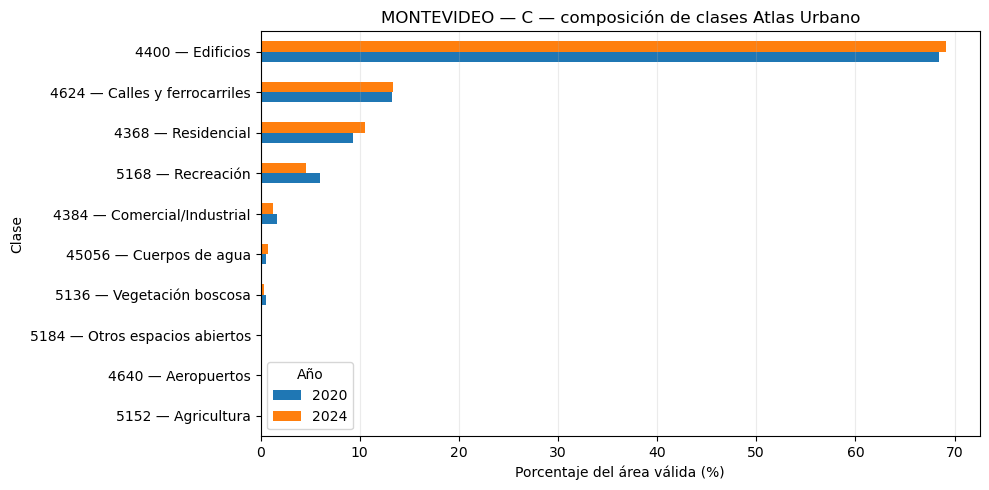

Figura guardada: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU\figures\au_uruguay_montevideo_c_variacion_area_por_clase.png


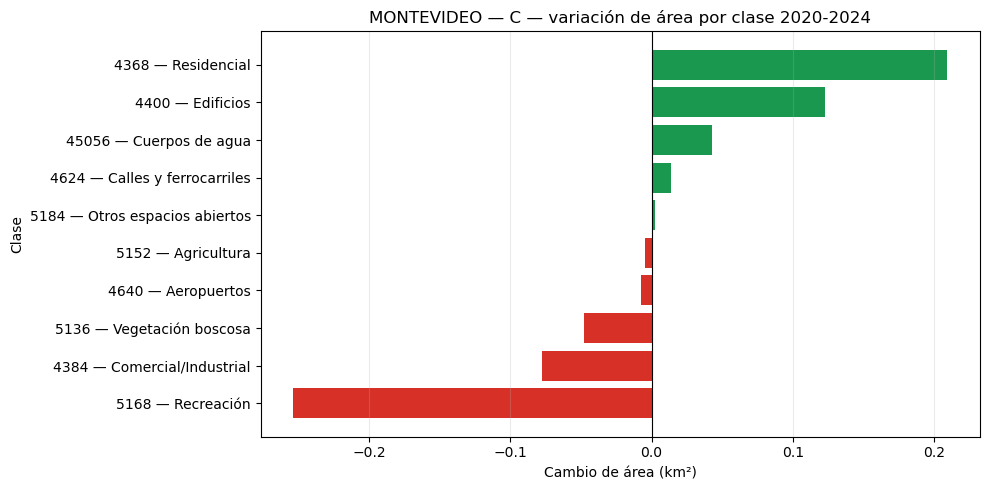

In [11]:
# ============================================================
# 7. DISTRIBUCIÓN DE CLASES Y VARIACIÓN MULTITEMPORAL
# ============================================================

def calcular_estadisticas_clases(arr, year):
    valid = np.ones(arr.shape, dtype=bool)
    for val in IGNORE_VALUES:
        valid &= arr != val
    values, counts = np.unique(arr[valid], return_counts=True)
    px_area = PX_AREA_KM2_ANALISIS
    total_area = counts.sum() * px_area
    rows = []
    for value, count in zip(values, counts):
        value = int(value)
        area = float(count * px_area)
        rows.append({"anio": year, "class_id": value, "class_name": nombre_clase(value), "area_km2": area, "porcentaje_area": 100 * area / total_area if total_area > 0 else 0, "pixeles": int(count), "es_construida": value in CLASES_CONSTRUIDAS})
    return pd.DataFrame(rows).sort_values("area_km2", ascending=False).reset_index(drop=True)

def comparar_clases(stats_2020, stats_2024):
    a = stats_2020[["class_id", "class_name", "area_km2", "porcentaje_area", "es_construida"]].rename(columns={"area_km2": f"area_{ANIO_1}_km2", "porcentaje_area": f"porcentaje_{ANIO_1}"})
    b = stats_2024[["class_id", "class_name", "area_km2", "porcentaje_area", "es_construida"]].rename(columns={"area_km2": f"area_{ANIO_2}_km2", "porcentaje_area": f"porcentaje_{ANIO_2}"})
    df = a.merge(b, on=["class_id", "class_name", "es_construida"], how="outer").fillna(0)
    df["delta_area_km2"] = df[f"area_{ANIO_2}_km2"] - df[f"area_{ANIO_1}_km2"]
    df["delta_porcentaje_puntos"] = df[f"porcentaje_{ANIO_2}"] - df[f"porcentaje_{ANIO_1}"]
    df["variacion_pct_relativa"] = np.where(df[f"area_{ANIO_1}_km2"] > 0, 100 * df["delta_area_km2"] / df[f"area_{ANIO_1}_km2"], np.nan)
    return df.sort_values("delta_area_km2", ascending=False).reset_index(drop=True)

stats_2020 = calcular_estadisticas_clases(arr_2020, ANIO_1)
stats_2024 = calcular_estadisticas_clases(arr_2024, ANIO_2)
stats_clases = pd.concat([stats_2020, stats_2024], ignore_index=True)
comparacion_clases = comparar_clases(stats_2020, stats_2024)
stats_clases.to_csv(out_dirs["tables"] / f"{base}_distribucion_clases_{ANIO_1}_{ANIO_2}.csv", index=False, encoding="utf-8-sig")
comparacion_clases.to_csv(out_dirs["tables"] / f"{base}_comparacion_clases_{ANIO_1}_{ANIO_2}.csv", index=False, encoding="utf-8-sig")
display(stats_clases.round(3))
display(comparacion_clases.round(3))

plot_df = stats_clases.copy()
plot_df["label"] = plot_df["class_id"].astype(str) + " — " + plot_df["class_name"]
pivot = plot_df.pivot_table(index="label", columns="anio", values="porcentaje_area", fill_value=0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]
fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(pivot))))
pivot.plot(kind="barh", ax=ax)
ax.set_title(f"{AREA_SELECCIONADA} — composición de clases Atlas Urbano")
ax.set_xlabel("Porcentaje del área válida (%)")
ax.set_ylabel("Clase")
ax.grid(axis="x", alpha=0.25)
ax.legend(title="Año")
plt.tight_layout()
guardar_figura(fig, out_dirs["figures"] / f"{base}_composicion_clases.png")
display_fig(fig)

df_var = comparacion_clases.copy()
df_var["label"] = df_var["class_id"].astype(str) + " — " + df_var["class_name"]
df_var = df_var.sort_values("delta_area_km2")
colors = np.where(df_var["delta_area_km2"] >= 0, "#1a9850", "#d73027")
fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(df_var))))
ax.barh(df_var["label"], df_var["delta_area_km2"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"{AREA_SELECCIONADA} — variación de área por clase {ANIO_1}-{ANIO_2}")
ax.set_xlabel("Cambio de área (km²)")
ax.set_ylabel("Clase")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
guardar_figura(fig, out_dirs["figures"] / f"{base}_variacion_area_por_clase.png")
display_fig(fig)

## 8. Superficie construida total

Agrupamos las clases urbanas construidas para evaluar el comportamiento agregado del tejido construido.

,anio,superficie_construida_km2,delta_km2
0,2020,16.003,NaN
1,2024,16.263,0.26


Figura guardada: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU\figures\au_uruguay_montevideo_c_superficie_construida_total.png


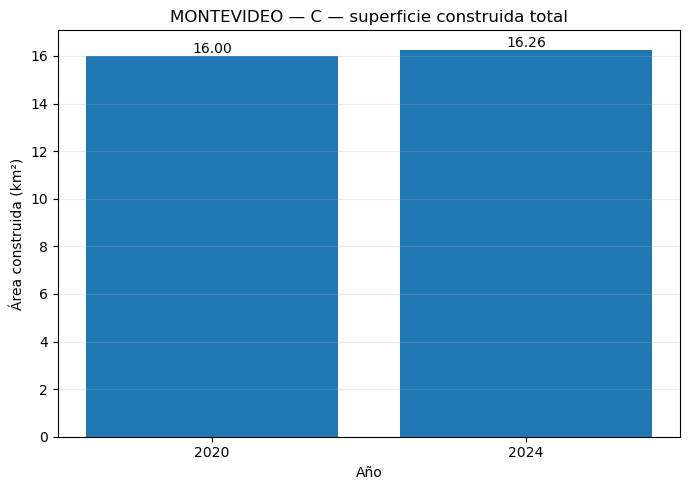

In [12]:
# ============================================================
# 8. SUPERFICIE CONSTRUIDA TOTAL
# ============================================================

area_construida_2020 = stats_2020.loc[stats_2020["es_construida"], "area_km2"].sum()
area_construida_2024 = stats_2024.loc[stats_2024["es_construida"], "area_km2"].sum()
superficie_construida_df = pd.DataFrame({"anio": [ANIO_1, ANIO_2], "superficie_construida_km2": [area_construida_2020, area_construida_2024]})
superficie_construida_df["delta_km2"] = superficie_construida_df["superficie_construida_km2"].diff()
superficie_construida_df.to_csv(out_dirs["tables"] / f"{base}_superficie_construida_total.csv", index=False, encoding="utf-8-sig")
display(superficie_construida_df.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(superficie_construida_df["anio"].astype(str), superficie_construida_df["superficie_construida_km2"])
ax.set_title(f"{AREA_SELECCIONADA} — superficie construida total")
ax.set_xlabel("Año")
ax.set_ylabel("Área construida (km²)")
ax.grid(axis="y", alpha=0.25)
for i, v in enumerate(superficie_construida_df["superficie_construida_km2"]): ax.text(i, v, f"{v:.2f}", ha="center", va="bottom")
plt.tight_layout(); guardar_figura(fig, out_dirs["figures"] / f"{base}_superficie_construida_total.png"); display_fig(fig)

## 9. Matriz de transición 2020 → 2024

La matriz de transición permite distinguir expansión urbana, pérdida de superficie construida y posibles reclasificaciones internas del producto.

In [13]:
# ============================================================
# 10. MATRIZ COMPLETA DE TRANSICIÓN 2020 → 2024
# ============================================================

valid_both = np.ones(arr_2020.shape, dtype=bool)
for val in IGNORE_VALUES:
    valid_both &= arr_2020 != val
    valid_both &= arr_2024 != val

trans_df = pd.DataFrame({"class_2020": arr_2020[valid_both].astype(int), "class_2024": arr_2024[valid_both].astype(int)})
matriz_transicion = trans_df.groupby(["class_2020", "class_2024"]).size().reset_index(name="pixeles")
matriz_transicion["area_km2"] = matriz_transicion["pixeles"] * PX_AREA_KM2_ANALISIS
matriz_transicion["nombre_2020"] = matriz_transicion["class_2020"].apply(nombre_clase)
matriz_transicion["nombre_2024"] = matriz_transicion["class_2024"].apply(nombre_clase)
matriz_transicion = matriz_transicion.sort_values("area_km2", ascending=False).reset_index(drop=True)
matriz_transicion.to_csv(out_dirs["tables"] / f"{base}_matriz_transicion_{ANIO_1}_{ANIO_2}.csv", index=False, encoding="utf-8-sig")
display(matriz_transicion.head(20).round(3))

,class_2020,class_2024,pixeles,area_km2,nombre_2020,nombre_2024
0,4400,4400,132542,10.154,Edificios,Edificios
1,4624,4624,20859,1.598,Calles y ferrocarriles,Calles y ferrocarriles
2,4400,4368,11459,0.878,Edificios,Residencial
3,4368,4400,10518,0.806,Residencial,Edificios
4,4368,4368,7761,0.595,Residencial,Residencial
5,4400,4624,6550,0.502,Edificios,Calles y ferrocarriles
6,4624,4400,6548,0.502,Calles y ferrocarriles,Edificios
7,5168,5168,5279,0.404,Recreación,Recreación
8,5168,4400,3975,0.305,Recreación,Edificios
9,5168,4368,2306,0.177,Recreación,Residencial


## 10. Origen de la expansión construida

Se identifican los píxeles que no eran construidos en 2020 y pasan a construidos en 2024.

Tipo de nueva superficie construida:


,class_id,class_name,area_km2,pixeles
2,4400,Edificios,0.357,4656
0,4368,Residencial,0.185,2415
3,4624,Calles y ferrocarriles,0.059,765
1,4384,Comercial/Industrial,0.044,575
4,4640,Aeropuertos,0.006,79


Principales transiciones hacia superficie construida:


,class_2020,class_2024,pixeles,area_km2,nombre_2020,nombre_2024,transicion
8,5168,4400,3975,0.305,Recreación,Edificios,5168 — Recreación → 4400 — Edificios
9,5168,4368,2306,0.177,Recreación,Residencial,5168 — Recreación → 4368 — Residencial
17,5168,4624,630,0.048,Recreación,Calles y ferrocarriles,5168 — Recreación → 4624 — Calles y ferrocarriles
22,5136,4400,471,0.036,Vegetación boscosa,Edificios,5136 — Vegetación boscosa → 4400 — Edificios
23,5168,4384,421,0.032,Recreación,Comercial/Industrial,5168 — Recreación → 4384 — Comercial/Industrial
33,45056,4400,136,0.010,Cuerpos de agua,Edificios,45056 — Cuerpos de agua → 4400 — Edificios
34,45056,4384,136,0.010,Cuerpos de agua,Comercial/Industrial,45056 — Cuerpos de agua → 4384 — Comercial/Ind...
38,45056,4624,107,0.008,Cuerpos de agua,Calles y ferrocarriles,45056 — Cuerpos de agua → 4624 — Calles y ferr...
39,5168,4640,79,0.006,Recreación,Aeropuertos,5168 — Recreación → 4640 — Aeropuertos
41,5184,4400,68,0.005,Otros espacios abiertos,Edificios,5184 — Otros espacios abiertos → 4400 — Edificios


Figura guardada: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU\figures\au_uruguay_montevideo_c_expansion_por_destino_urbano.png


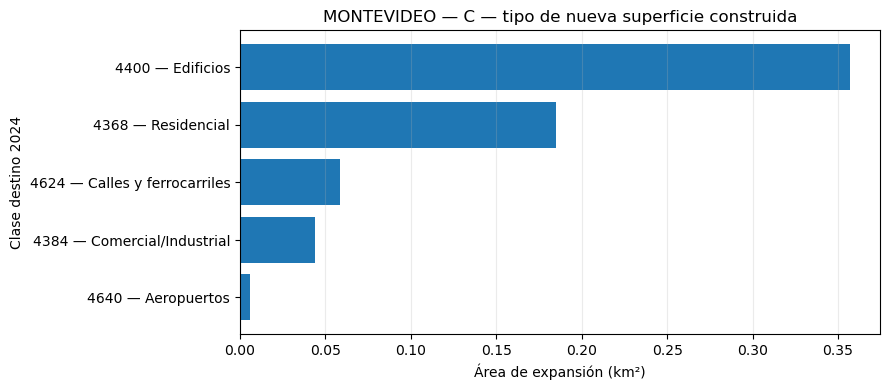

Figura guardada: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU\figures\au_uruguay_montevideo_c_origen_expansion_construida.png


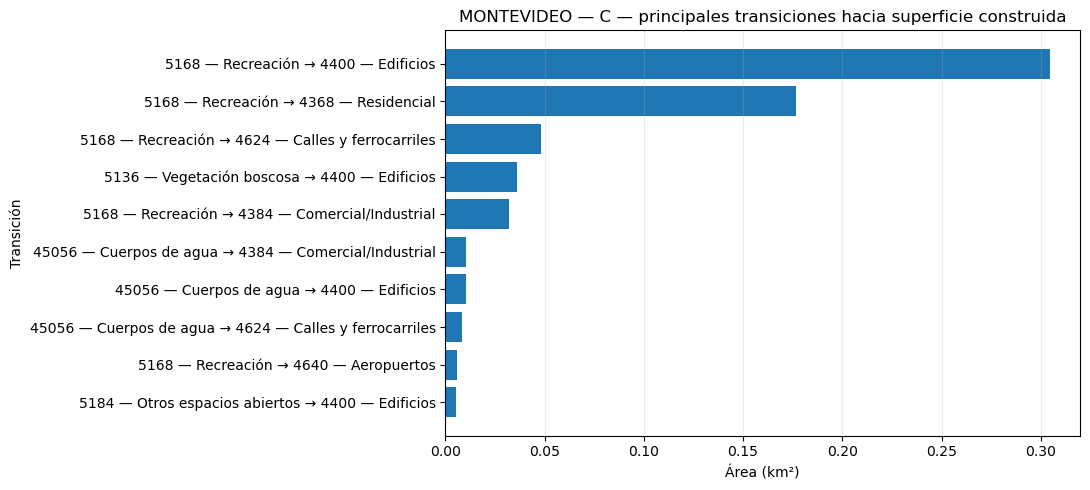

In [14]:
# ============================================================
# 11. ORIGEN Y TIPO DE NUEVA SUPERFICIE CONSTRUIDA
# ============================================================

built_2020 = np.isin(arr_2020, list(CLASES_CONSTRUIDAS.keys())) & valid_both
built_2024 = np.isin(arr_2024, list(CLASES_CONSTRUIDAS.keys())) & valid_both
permanencia_construida = built_2020 & built_2024
perdida_construida_mask = built_2020 & (~built_2024)
ganancia_construida_mask = (~built_2020) & built_2024

dest_values, dest_counts = np.unique(arr_2024[ganancia_construida_mask], return_counts=True)
expansion_destino_df = pd.DataFrame({"class_id": dest_values.astype(int), "class_name": [nombre_clase(v) for v in dest_values], "area_km2": dest_counts * PX_AREA_KM2_ANALISIS, "pixeles": dest_counts.astype(int)}).sort_values("area_km2", ascending=False)
expansion_destino_df.to_csv(out_dirs["tables"] / f"{base}_expansion_por_destino_urbano.csv", index=False, encoding="utf-8-sig")
print("Tipo de nueva superficie construida:"); display(expansion_destino_df.round(3))

origen_destino = matriz_transicion[(~matriz_transicion["class_2020"].isin(CLASES_CONSTRUIDAS.keys())) & (matriz_transicion["class_2024"].isin(CLASES_CONSTRUIDAS.keys()))].copy()
origen_destino["transicion"] = origen_destino["class_2020"].astype(str) + " — " + origen_destino["nombre_2020"] + " → " + origen_destino["class_2024"].astype(str) + " — " + origen_destino["nombre_2024"]
origen_destino = origen_destino.sort_values("area_km2", ascending=False)
origen_destino.to_csv(out_dirs["tables"] / f"{base}_origen_expansion_construida.csv", index=False, encoding="utf-8-sig")
print("Principales transiciones hacia superficie construida:"); display(origen_destino.head(15).round(3))

if not expansion_destino_df.empty:
    plot_df = expansion_destino_df.copy(); plot_df["label"] = plot_df["class_id"].astype(str) + " — " + plot_df["class_name"]; plot_df = plot_df.sort_values("area_km2")
    fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(plot_df))))
    ax.barh(plot_df["label"], plot_df["area_km2"])
    ax.set_title(f"{AREA_SELECCIONADA} — tipo de nueva superficie construida")
    ax.set_xlabel("Área de expansión (km²)"); ax.set_ylabel("Clase destino 2024"); ax.grid(axis="x", alpha=0.25)
    plt.tight_layout(); guardar_figura(fig, out_dirs["figures"] / f"{base}_expansion_por_destino_urbano.png"); display_fig(fig)

if not origen_destino.empty:
    plot_df = origen_destino.head(10).sort_values("area_km2")
    fig, ax = plt.subplots(figsize=(11, max(5, 0.5 * len(plot_df))))
    ax.barh(plot_df["transicion"], plot_df["area_km2"])
    ax.set_title(f"{AREA_SELECCIONADA} — principales transiciones hacia superficie construida")
    ax.set_xlabel("Área (km²)"); ax.set_ylabel("Transición"); ax.grid(axis="x", alpha=0.25)
    plt.tight_layout(); guardar_figura(fig, out_dirs["figures"] / f"{base}_origen_expansion_construida.png"); display_fig(fig)

## 11. Mapas de cambio urbano

Se generan mapas de cambio/sin cambio, cambio de superficie construida y transición urbana interpretada.

,codigo,categoria,pixeles,area_km2
0,1,Permanencia construida,203776,15.611
1,2,Pérdida construida,5105,0.391
2,3,Ganancia construida,8490,0.650
3,4,Resto área válida,7894,0.605


Figura guardada: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU\figures\au_uruguay_montevideo_c_mapa_cambio_sin_cambio.png


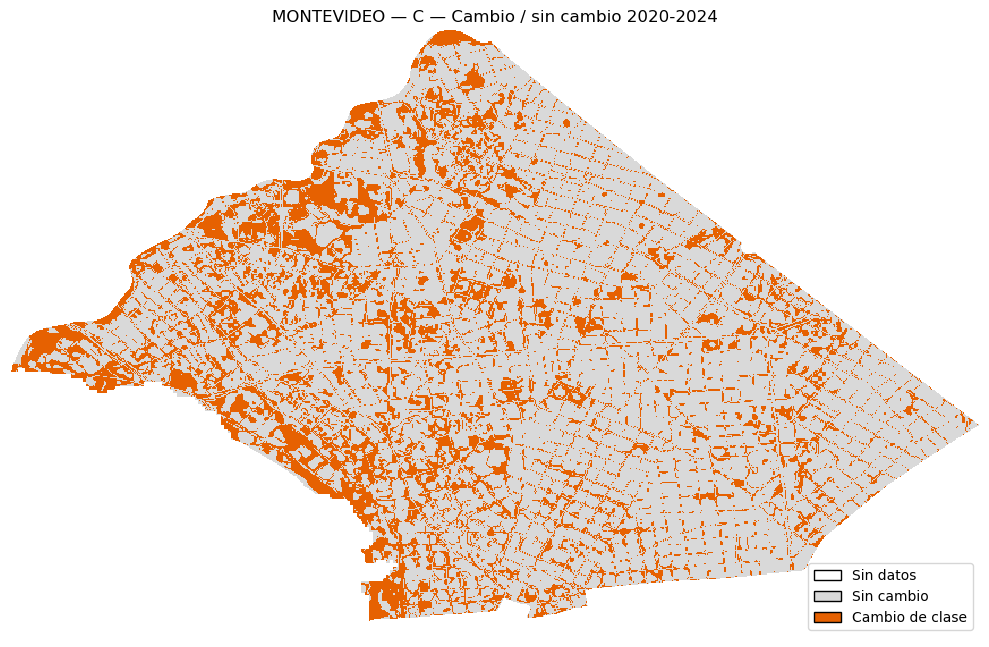

Figura guardada: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU\figures\au_uruguay_montevideo_c_mapa_cambio_construido_integrado.png


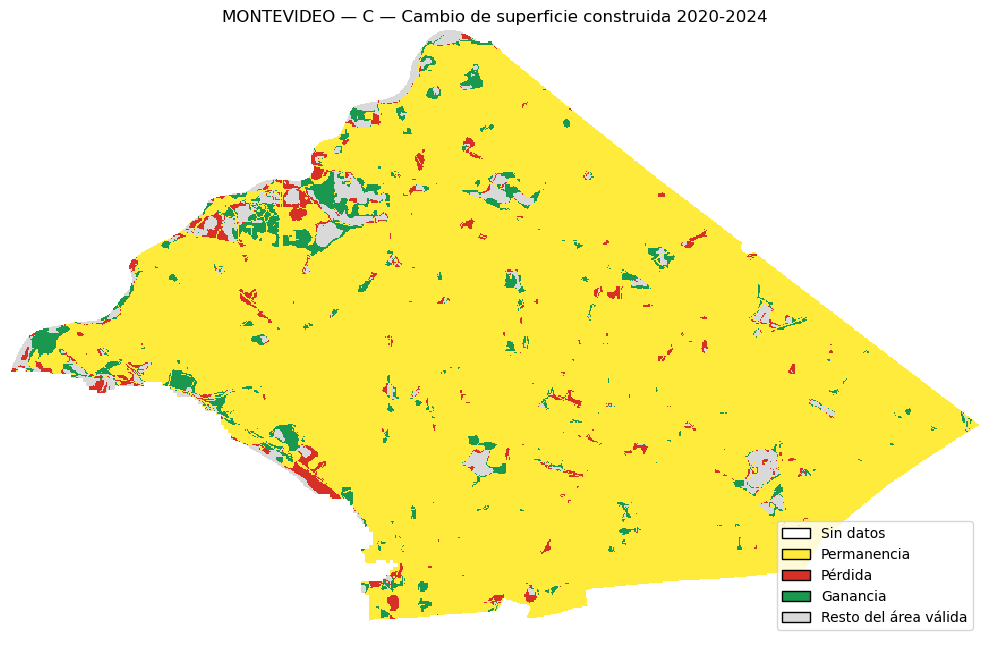

Figura guardada: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU\figures\au_uruguay_montevideo_c_mapa_transicion_urbana_interpretada.png


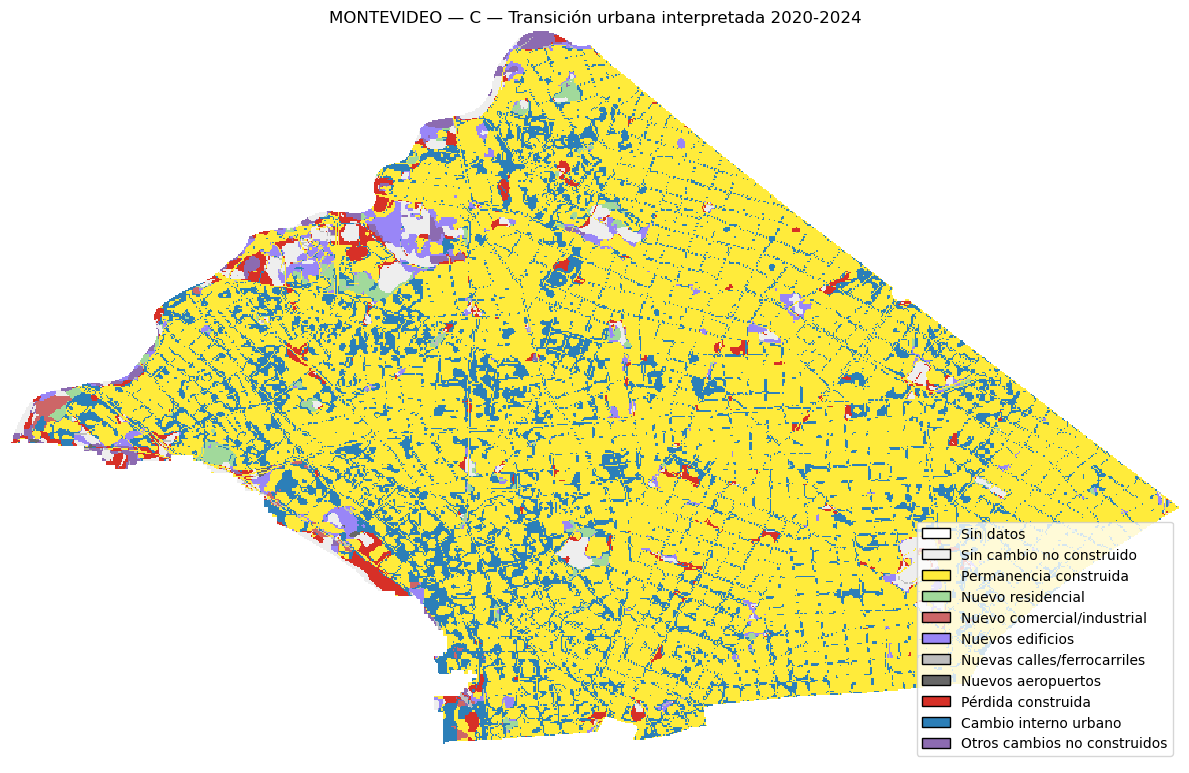

In [15]:
# ============================================================
# 11. MAPAS DE CAMBIO URBANO
# ============================================================

mapa_cambio_simple = np.zeros(arr_2020.shape, dtype=np.uint8)
mapa_cambio_simple[valid_both & (arr_2020 == arr_2024)] = 1
mapa_cambio_simple[valid_both & (arr_2020 != arr_2024)] = 2

mapa_cambio_construido = np.zeros(arr_2020.shape, dtype=np.uint8)
resto_area_valida = valid_both & (~permanencia_construida) & (~perdida_construida_mask) & (~ganancia_construida_mask)
mapa_cambio_construido[permanencia_construida] = 1
mapa_cambio_construido[perdida_construida_mask] = 2
mapa_cambio_construido[ganancia_construida_mask] = 3
mapa_cambio_construido[resto_area_valida] = 4

mapa_transicion_urbana = np.zeros(arr_2020.shape, dtype=np.uint8)
mapa_transicion_urbana[valid_both & (~built_2020) & (~built_2024) & (arr_2020 == arr_2024)] = 1
mapa_transicion_urbana[permanencia_construida & (arr_2020 == arr_2024)] = 2
mapa_transicion_urbana[ganancia_construida_mask & (arr_2024 == 4368)] = 3
mapa_transicion_urbana[ganancia_construida_mask & (arr_2024 == 4384)] = 4
mapa_transicion_urbana[ganancia_construida_mask & (arr_2024 == 4400)] = 5
mapa_transicion_urbana[ganancia_construida_mask & (arr_2024 == 4624)] = 6
mapa_transicion_urbana[ganancia_construida_mask & (arr_2024 == 4640)] = 7
mapa_transicion_urbana[perdida_construida_mask] = 8
mapa_transicion_urbana[built_2020 & built_2024 & (arr_2020 != arr_2024)] = 9
mapa_transicion_urbana[valid_both & (~built_2020) & (~built_2024) & (arr_2020 != arr_2024)] = 10

resumen_cambio_construido = pd.DataFrame([
    {"codigo": 1, "categoria": "Permanencia construida", "pixeles": int((mapa_cambio_construido == 1).sum()), "area_km2": float((mapa_cambio_construido == 1).sum() * PX_AREA_KM2_ANALISIS)},
    {"codigo": 2, "categoria": "Pérdida construida", "pixeles": int((mapa_cambio_construido == 2).sum()), "area_km2": float((mapa_cambio_construido == 2).sum() * PX_AREA_KM2_ANALISIS)},
    {"codigo": 3, "categoria": "Ganancia construida", "pixeles": int((mapa_cambio_construido == 3).sum()), "area_km2": float((mapa_cambio_construido == 3).sum() * PX_AREA_KM2_ANALISIS)},
    {"codigo": 4, "categoria": "Resto área válida", "pixeles": int((mapa_cambio_construido == 4).sum()), "area_km2": float((mapa_cambio_construido == 4).sum() * PX_AREA_KM2_ANALISIS)},
])
resumen_cambio_construido.to_csv(out_dirs["tables"] / f"{base}_resumen_cambio_construido.csv", index=False, encoding="utf-8-sig")
display(resumen_cambio_construido.round(3))

CAMBIO_SIMPLE_INFO = {0: {"label": "Sin datos", "color": "#ffffff"}, 1: {"label": "Sin cambio", "color": "#d9d9d9"}, 2: {"label": "Cambio de clase", "color": "#e66101"}}
CAMBIO_CONSTRUIDO_INFO = {0: {"label": "Sin datos", "color": "#ffffff"}, 1: {"label": "Permanencia", "color": "#ffeb3b"}, 2: {"label": "Pérdida", "color": "#d73027"}, 3: {"label": "Ganancia", "color": "#1a9850"}, 4: {"label": "Resto del área válida", "color": "#d9d9d9"}}
TRANSICION_URBANA_INFO = {0: {"label": "Sin datos", "color": "#ffffff"}, 1: {"label": "Sin cambio no construido", "color": "#eeeeee"}, 2: {"label": "Permanencia construida", "color": "#ffeb3b"}, 3: {"label": "Nuevo residencial", "color": "#a1d99b"}, 4: {"label": "Nuevo comercial/industrial", "color": "#cd6667"}, 5: {"label": "Nuevos edificios", "color": "#9986f7"}, 6: {"label": "Nuevas calles/ferrocarriles", "color": "#bdbdbd"}, 7: {"label": "Nuevos aeropuertos", "color": "#676767"}, 8: {"label": "Pérdida construida", "color": "#d73027"}, 9: {"label": "Cambio interno urbano", "color": "#2c7fb8"}, 10: {"label": "Otros cambios no construidos", "color": "#8c6bb1"}}

def cmap_from_info(info_dict):
    codes = sorted(info_dict.keys()); colors = [info_dict[c]["color"] for c in codes]; bounds = [c - 0.5 for c in codes] + [codes[-1] + 0.5]
    return ListedColormap(colors), BoundaryNorm(bounds, len(colors)), codes

def plot_mapa_cambio(arr, info_dict, title, fig_path=None, figsize=(10, 8)):
    cmap, norm, codes = cmap_from_info(info_dict)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(arr, cmap=cmap, norm=norm, extent=plotting_extent(arr, profile_2020["transform"]), interpolation="nearest")
    ax.set_title(title); ax.set_axis_off()
    present = [c for c in codes if np.any(arr == c)]
    patches = [Patch(facecolor=info_dict[c]["color"], edgecolor="black", label=info_dict[c]["label"]) for c in present]
    if patches: ax.legend(handles=patches, loc="lower right", frameon=True)
    plt.tight_layout()
    if fig_path is not None: guardar_figura(fig, fig_path)
    display_fig(fig)

plot_mapa_cambio(mapa_cambio_simple, CAMBIO_SIMPLE_INFO, f"{AREA_SELECCIONADA} — Cambio / sin cambio {ANIO_1}-{ANIO_2}", out_dirs["figures"] / f"{base}_mapa_cambio_sin_cambio.png")
plot_mapa_cambio(mapa_cambio_construido, CAMBIO_CONSTRUIDO_INFO, f"{AREA_SELECCIONADA} — Cambio de superficie construida {ANIO_1}-{ANIO_2}", out_dirs["figures"] / f"{base}_mapa_cambio_construido_integrado.png")
plot_mapa_cambio(mapa_transicion_urbana, TRANSICION_URBANA_INFO, f"{AREA_SELECCIONADA} — Transición urbana interpretada {ANIO_1}-{ANIO_2}", out_dirs["figures"] / f"{base}_mapa_transicion_urbana_interpretada.png", figsize=(12, 9))

## 12. Diagnóstico especial: clase Residencial

Este bloque revisa las transiciones asociadas a `4368 — Residencial`, útil cuando aparece una pérdida residencial cuestionable.

In [26]:
# ============================================================
# 13. DIAGNÓSTICO DINÁMICO — CLASE DE INTERÉS
# ============================================================

import ipywidgets as widgets
from IPython.display import display, clear_output
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


# ------------------------------------------------------------
# Simbología del diagnóstico
# ------------------------------------------------------------

DIAGNOSTICO_CLASE_INFO = {
    0: {"label": "Sin datos", "color": "#ffffff"},
    1: {"label": "Sin presencia / sin cambio de interés", "color": "#eeeeee"},
    2: {"label": "Permanencia", "color": "#ffeb3b"},
    3: {"label": "Pérdida", "color": "#d73027"},
    4: {"label": "Ganancia", "color": "#2c7fb8"},
}


# ------------------------------------------------------------
# Diagnóstico tabular
# ------------------------------------------------------------

def diagnosticar_transiciones_clase(arr_2020, arr_2024, clase_interes):

    valid_2020 = np.ones(arr_2020.shape, dtype=bool)
    valid_2024 = np.ones(arr_2024.shape, dtype=bool)

    for val in IGNORE_VALUES:
        valid_2020 &= arr_2020 != val
        valid_2024 &= arr_2024 != val

    valid = valid_2020 & valid_2024

    c20 = valid & (arr_2020 == clase_interes)
    c24 = valid & (arr_2024 == clase_interes)

    permanencia = c20 & c24
    perdida = c20 & (~c24)
    ganancia = (~c20) & c24 & valid

    nombre = nombre_clase(clase_interes)

    resumen_df = pd.DataFrame([
        {
            "indicador": f"{nombre} {ANIO_1}",
            "area_km2": c20.sum() * PX_AREA_KM2_ANALISIS,
            "pixeles": int(c20.sum()),
        },
        {
            "indicador": f"{nombre} {ANIO_2}",
            "area_km2": c24.sum() * PX_AREA_KM2_ANALISIS,
            "pixeles": int(c24.sum()),
        },
        {
            "indicador": f"Permanencia {nombre}",
            "area_km2": permanencia.sum() * PX_AREA_KM2_ANALISIS,
            "pixeles": int(permanencia.sum()),
        },
        {
            "indicador": f"Pérdida {nombre}",
            "area_km2": perdida.sum() * PX_AREA_KM2_ANALISIS,
            "pixeles": int(perdida.sum()),
        },
        {
            "indicador": f"Ganancia {nombre}",
            "area_km2": ganancia.sum() * PX_AREA_KM2_ANALISIS,
            "pixeles": int(ganancia.sum()),
        },
        {
            "indicador": f"Cambio neto {nombre}",
            "area_km2": (c24.sum() - c20.sum()) * PX_AREA_KM2_ANALISIS,
            "pixeles": int(c24.sum() - c20.sum()),
        },
    ])

    vals, counts = np.unique(
        arr_2024[perdida],
        return_counts=True,
    )

    perdida_hacia_df = pd.DataFrame({
        "clase_2024": vals.astype(int),
        "nombre_clase_2024": [nombre_clase(v) for v in vals],
        "area_km2": counts * PX_AREA_KM2_ANALISIS,
        "pixeles": counts.astype(int),
    }).sort_values(
        "area_km2",
        ascending=False,
    )

    vals, counts = np.unique(
        arr_2020[ganancia],
        return_counts=True,
    )

    ganancia_desde_df = pd.DataFrame({
        "clase_2020": vals.astype(int),
        "nombre_clase_2020": [nombre_clase(v) for v in vals],
        "area_km2": counts * PX_AREA_KM2_ANALISIS,
        "pixeles": counts.astype(int),
    }).sort_values(
        "area_km2",
        ascending=False,
    )

    return (
        resumen_df,
        perdida_hacia_df,
        ganancia_desde_df,
    )


# ------------------------------------------------------------
# Mapa categórico de diagnóstico
# ------------------------------------------------------------

def crear_mapa_diagnostico_clase(
    arr_2020,
    arr_2024,
    clase_interes,
):

    valid_2020 = np.ones(arr_2020.shape, dtype=bool)
    valid_2024 = np.ones(arr_2024.shape, dtype=bool)

    for val in IGNORE_VALUES:
        valid_2020 &= arr_2020 != val
        valid_2024 &= arr_2024 != val

    valid = valid_2020 & valid_2024

    c20 = valid & (arr_2020 == clase_interes)
    c24 = valid & (arr_2024 == clase_interes)

    permanencia = c20 & c24
    perdida = c20 & (~c24)
    ganancia = (~c20) & c24

    mapa = np.zeros(
        arr_2020.shape,
        dtype=np.uint8,
    )

    mapa[valid] = 1
    mapa[permanencia] = 2
    mapa[perdida] = 3
    mapa[ganancia] = 4

    return mapa


# ------------------------------------------------------------
# Clases disponibles
# ------------------------------------------------------------

clases_disponibles = sorted([
    int(v)
    for v in np.unique(
        np.concatenate([
            arr_2020.ravel(),
            arr_2024.ravel(),
        ])
    )
    if v not in IGNORE_VALUES
])

opciones_clases = [
    (
        f"{codigo} - {nombre_clase(codigo)}",
        codigo,
    )
    for codigo in clases_disponibles
]


# ------------------------------------------------------------
# Widgets
# ------------------------------------------------------------

widget_clase = widgets.Dropdown(
    options=opciones_clases,
    value=4368 if 4368 in clases_disponibles else clases_disponibles[0],
    description="Clase:",
    layout=widgets.Layout(width="500px"),
)

boton_diagnostico = widgets.Button(
    description="Actualizar diagnóstico",
    button_style="primary",
    icon="refresh",
    layout=widgets.Layout(width="250px"),
)

salida_diagnostico = widgets.Output()


# ------------------------------------------------------------
# Ejecución del diagnóstico
# ------------------------------------------------------------

def ejecutar_diagnostico_clase(_=None):

    with salida_diagnostico:
        clear_output(wait=True)

        clase_interes = widget_clase.value
        nombre = nombre_clase(clase_interes)

        nombre_archivo = (
            str(nombre)
            .lower()
            .replace(" ", "_")
            .replace("/", "_"))
        # ----------------------------------------------------
        # Tablas
        # ----------------------------------------------------
        (
            resumen_df,
            perdida_hacia_df,
            ganancia_desde_df,
        ) = diagnosticar_transiciones_clase(
            arr_2020,
            arr_2024,
            clase_interes,)
        print(
            f"Diagnóstico de clase: "
            f"{clase_interes} - {nombre}")

        print("\nResumen")
        display(resumen_df.round(3))
        print(
            f"\nClase {ANIO_1} que dejó de ser "
            f"{nombre} en {ANIO_2}")
        display(perdida_hacia_df.round(3))
        print(
            f"\nNueva superficie {nombre} en {ANIO_2} "
            f"proveniente de otras clases de {ANIO_1}")
        display(ganancia_desde_df.round(3))
        # ----------------------------------------------------
        # Crear mapa
        # ----------------------------------------------------
        mapa_diagnostico = crear_mapa_diagnostico_clase(
            arr_2020,
            arr_2024,
            clase_interes,)
        # ----------------------------------------------------
        # Visualización PNG
        # ----------------------------------------------------
        colores = [
            DIAGNOSTICO_CLASE_INFO[i]["color"]
            for i in range(5)
        ]
        cmap = ListedColormap(colores)
        fig, ax = plt.subplots(
            figsize=(12, 9),
            dpi=120,
        )
        ax.imshow(
            mapa_diagnostico,
            cmap=cmap,
            vmin=0,
            vmax=4,)
        ax.set_title(
            f"{nombre} — diagnóstico espacial "
            f"{ANIO_1}-{ANIO_2}",
            fontsize=16,)

        ax.axis("off")
        leyenda = [
            Patch(
                facecolor=DIAGNOSTICO_CLASE_INFO[i]["color"],
                edgecolor="gray",
                label=DIAGNOSTICO_CLASE_INFO[i]["label"],
            )
            for i in range(1, 5)
        ]
        ax.legend(
            handles=leyenda,
            loc="lower right",
            frameon=True,)

        plt.tight_layout()
        # ----------------------------------------------------
        # Guardar PNG
        # ----------------------------------------------------
        ruta_png = (
            out_dirs["figures"]
            / f"{base}_diagnostico_{nombre_archivo}.png")
        fig.savefig(
            ruta_png,
            dpi=300,
            bbox_inches="tight",)
        plt.show()
        # ---------------------------------------------------
        # Guardar GeoTIFF
        # ----------------------------------------------------
        ruta_tif = (
            out_dirs["qgis"]
            / f"{base}_diagnostico_{nombre_archivo}.tif")
        exportar_raster(
            mapa_diagnostico,
            profile_2020,
            ruta_tif,
            nodata=0,
            dtype="uint8",
            info_colores=DIAGNOSTICO_CLASE_INFO,)

        # ----------------------------------------------------
        # Guardar CSV
        # ----------------------------------------------------
        resumen_df.to_csv(
            out_dirs["tables"]
            / f"{base}_diagnostico_{nombre_archivo}_resumen.csv",
            index=False,
            encoding="utf-8-sig",)
        perdida_hacia_df.to_csv(
            out_dirs["tables"]
            / f"{base}_diagnostico_{nombre_archivo}_perdida_hacia_{ANIO_2}.csv",
            index=False,
            encoding="utf-8-sig",)

        ganancia_desde_df.to_csv(
            out_dirs["tables"]
            / f"{base}_diagnostico_{nombre_archivo}_ganancia_desde_{ANIO_1}.csv",
            index=False,
            encoding="utf-8-sig",)

        print("\nResultados guardados correctamente:")
        print("PNG :", ruta_png)
        print("TIF :", ruta_tif)
        print("CSV :", out_dirs["tables"])

# ------------------------------------------------------------
# Interfaz
# ------------------------------------------------------------
boton_diagnostico.on_click(
    ejecutar_diagnostico_clase)

display(
    widgets.VBox([
        widgets.HTML(
            "<h4>Seleccione la clase de interés</h4>"
        ),
        widget_clase,
        boton_diagnostico,
        salida_diagnostico,
    ])
)

ejecutar_diagnostico_clase()

## 14. Exportación para QGIS

Se exportan recortes base y mapas derivados como GeoTIFF, además del área de análisis.

In [22]:
# ============================================================
# 14. EXPORTACIÓN PARA QGIS
# ============================================================

# ----------------------------------------------------------
# Atlas Urbano 2020 y 2024
# Se exportan con el estilo QML oficial del producto
# ------------------------------------------------------------
au2020_tif = exportar_raster(
    arr_2020,
    profile_2020,
    out_dirs["qgis"] / f"{base}_au_{ANIO_1}.tif",
    nodata=0,)
au2024_tif = exportar_raster(
    arr_2024,
    profile_2020,
    out_dirs["qgis"] / f"{base}_au_{ANIO_2}.tif",
    nodata=0,)
copiar_qml_si_existe(au2020_tif)
copiar_qml_si_existe(au2024_tif)
# ------------------------------------------------------------
# Mapas derivados de cambio
# Se incorpora la paleta directamente al GeoTIFF
# ------------------------------------------------------------
exportar_raster(
    mapa_cambio_simple,
    profile_2020,
    out_dirs["qgis"] / f"{base}_mapa_cambio_sin_cambio.tif",
    nodata=0,
    dtype="uint8",
    info_colores=CAMBIO_SIMPLE_INFO,)

exportar_raster(
    mapa_cambio_construido,
    profile_2020,
    out_dirs["qgis"] / f"{base}_mapa_cambio_construido.tif",
    nodata=0,
    dtype="uint8",
    info_colores=CAMBIO_CONSTRUIDO_INFO,)

exportar_raster(
    mapa_transicion_urbana,
    profile_2020,
    out_dirs["qgis"] / f"{base}_mapa_transicion_urbana_interpretada.tif",
    nodata=0,
    dtype="uint8",
    info_colores=TRANSICION_URBANA_INFO,)

# ------------------------------------------------------------
# Área de análisis
# ------------------------------------------------------------
area_gpkg = (
    out_dirs["qgis"]
    / f"{base}_area_analisis.gpkg")

analysis_gdf.to_file(
    area_gpkg,
    driver="GPKG",)
print("Área de análisis exportada:", area_gpkg)

Raster exportado: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU\qgis\au_uruguay_montevideo_c_au_2020.tif
Raster exportado: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU\qgis\au_uruguay_montevideo_c_au_2024.tif
Raster exportado: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU\qgis\au_uruguay_montevideo_c_mapa_cambio_sin_cambio.tif
Raster exportado: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU\qgis\au_uruguay_montevideo_c_mapa_cambio_construido.tif
Raster exportado: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU\qgis\au_uruguay_montevideo_c_mapa_transicion_urbana_interpretada.tif
Área de análisis exportada: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU\qgis\au_uruguay_montevideo_c_area_analisis.gpkg


In [18]:
# ============================================================
# 15. RESUMEN FINAL AUTOMÁTICO
# ============================================================

cambio_neto_construido = area_construida_2024 - area_construida_2020
permanencia_area = resumen_cambio_construido.loc[resumen_cambio_construido["codigo"] == 1, "area_km2"].iloc[0]
perdida_area = resumen_cambio_construido.loc[resumen_cambio_construido["codigo"] == 2, "area_km2"].iloc[0]
ganancia_area = resumen_cambio_construido.loc[resumen_cambio_construido["codigo"] == 3, "area_km2"].iloc[0]
principal_destino_txt = "Sin nueva superficie construida"
if not expansion_destino_df.empty:
    r = expansion_destino_df.iloc[0]
    principal_destino_txt = f"{int(r['class_id'])} — {r['class_name']}: {r['area_km2']:.3f} km²"
principal_origen_txt = "Sin transiciones hacia superficie construida"
if not origen_destino.empty:
    r = origen_destino.iloc[0]
    principal_origen_txt = f"{int(r['class_2020'])} — {r['nombre_2020']}: {r['area_km2']:.3f} km²"

resumen_txt = f"""
RESUMEN FINAL
{'=' * 80}
Área de estudio: {AREA_SELECCIONADA}
Departamento: {DEPTO_SELECCIONADO}
Municipio/escala: {MUNICIPIO_SELECCIONADO}

Superficie construida {ANIO_1}: {area_construida_2020:.3f} km²
Superficie construida {ANIO_2}: {area_construida_2024:.3f} km²
Cambio neto de superficie construida: {cambio_neto_construido:.3f} km²
Permanencia construida: {permanencia_area:.3f} km²
Pérdida construida: {perdida_area:.3f} km²
Ganancia construida: {ganancia_area:.3f} km²

Principal tipo de nueva superficie construida:
- {principal_destino_txt}

Principal cobertura reemplazada por nueva superficie construida:
- {principal_origen_txt}

Archivos exportados:
Figuras: {out_dirs['figures']}
Tablas: {out_dirs['tables']}
QGIS: {out_dirs['qgis']}
"""
print(resumen_txt)
with open(out_dirs["tables"] / f"{base}_resumen_final.txt", "w", encoding="utf-8") as f: f.write(resumen_txt)


RESUMEN FINAL
Área de estudio: MONTEVIDEO — C
Departamento: MONTEVIDEO
Municipio/escala: C

Superficie construida 2020: 16.003 km²
Superficie construida 2024: 16.263 km²
Cambio neto de superficie construida: 0.260 km²
Permanencia construida: 15.611 km²
Pérdida construida: 0.391 km²
Ganancia construida: 0.650 km²

Principal tipo de nueva superficie construida:
- 4400 — Edificios: 0.357 km²

Principal cobertura reemplazada por nueva superficie construida:
- 5168 — Recreación: 0.305 km²

Archivos exportados:
Figuras: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU\figures
Tablas: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU\tables
QGIS: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU\qgis



### Cierre interpretativo

Evita interpretar un cambio neto de una clase individual como cambio territorial directo sin mirar la matriz de transición. Ejemplo: Una disminución de `4368 — Residencial` puede estar asociada a cambios internos hacia calles, edificios, recreación u otras clases urbanas.